# Pandas

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

## Create data structures

In [2]:
S355_stress = [0, 355, 490]

stress_series = pd.Series(S355_stress,dtype=float)

print(stress_series)

0      0.0
1    355.0
2    490.0
dtype: float64


In [3]:
S355_strain = [0, 0.001, 0.075]

strain_series = pd.Series(S355_strain, name="Strain")

print(strain_series)

0    0.000
1    0.001
2    0.075
Name: Strain, dtype: float64


In [4]:
# Dataframe from a dictionary
data = {
  "stress": stress_series,
  "strain": [0, 0.001, 0.075]
}

df_S355 = pd.DataFrame(data)

df_S355

,stress,strain
0,0.0,0.000
1,355.0,0.001
2,490.0,0.075


In [5]:
# Copying DataFrames
df_S235 = df_S355.copy()
df_S235["stress"] = [0, 235.0, 360.0]
df_S235

,stress,strain
0,0.0,0.000
1,235.0,0.001
2,360.0,0.075


In [6]:
df_S355

,stress,strain
0,0.0,0.000
1,355.0,0.001
2,490.0,0.075


In [7]:
# Labelled indices
# Option 1 - change the existing DataFrame indices
df_S355_labelled = df_S355.copy()
df_S355_labelled.index = ["zero", "yield", "ultimate"]
# Option 2 - set indices as you create the DataFrame
data = {"stress": [0, 355.0, 490.0], "strain": [0, 0.001, 0.075]}
df_S355_labelled = pd.DataFrame(data, index = ["zero", "yield", "ultimate"])

df_S355_labelled

,stress,strain
zero,0.0,0.000
yield,355.0,0.001
ultimate,490.0,0.075


## Access data

In [8]:
# Error
# df_S355[1]

In [9]:
# returns column as series
df_S355["stress"]

0      0.0
1    355.0
2    490.0
Name: stress, dtype: float64

In [10]:
# returns column as dataframe
df_S355[["stress"]]

,stress
0,0.0
1,355.0
2,490.0


In [11]:
# row, access by label
df_S355_labelled.loc["yield"]

stress    355.000
strain      0.001
Name: yield, dtype: float64

In [12]:
# row, access by label
df_S355.loc[1]

stress    355.000
strain      0.001
Name: 1, dtype: float64

In [13]:
# chained indexing - not recommended!
# If that row (Series) has mixed types across its entries, pandas might get confused
df_S355_labelled.loc["yield"]["stress"]

np.float64(355.0)

In [14]:
# loc[row labels, column labels]
df_S355_labelled.loc["yield","stress"]

np.float64(355.0)

In [15]:
df_S355_labelled.loc["yield",["strain","stress"]]

strain      0.001
stress    355.000
Name: yield, dtype: float64

In [16]:
# row, access by index
df_S355_labelled.iloc[1]

stress    355.000
strain      0.001
Name: yield, dtype: float64

In [17]:
# row 1, column 0
print(df_S355.iloc[1,0])
print(df_S355.iloc[1,df_S355.columns.get_loc("stress")])

355.0
355.0


In [18]:
# at returns only scalar values, cannot use for filtering
# at[row label, column label]
df_S355_labelled.at["yield","stress"]

np.float64(355.0)

In [19]:
df_S355.iat[1, 1]

np.float64(0.001)

## Import/export data

In [20]:
# remove in final version
df = pd.read_csv("steel_data_original.csv",usecols=[1,2,16])
df.columns = ['displacement','force','strain']
df.to_csv('steel_data.csv', index=False)

In [21]:
# read csv, define manually column headers
df = pd.read_csv("steel_data.csv")
df.columns = ['displacement','force','strain']
df

,displacement,force,strain
0,0.000,0.000,0.000
1,0.000,0.000,0.000
2,0.000,0.000,0.000
3,0.000,0.000,0.000
4,0.000,0.000,0.000
...,...,...,...
403,12.163,-0.233,87332.689
404,12.229,-0.216,87290.022
405,12.229,-0.215,87257.593
406,12.246,-0.218,87236.164


In [22]:
# save to csv, including the column headers
df.to_csv('steel_data_labelled.csv', index=False)

In [23]:
# read csv with column headers, use only columns 1 and 3
df = pd.read_csv("steel_data_labelled.csv",usecols=[0,2])
df

,displacement,strain
0,0.000,0.000
1,0.000,0.000
2,0.000,0.000
3,0.000,0.000
4,0.000,0.000
...,...,...
403,12.163,87332.689
404,12.229,87290.022
405,12.229,87257.593
406,12.246,87236.164


In [24]:
# read csv with space delimited data
df = pd.read_csv("steel_data_space_delimited.csv", delimiter = " ")
df

,displacement,force,strain
0,0.000,0.000,0.000
1,0.000,0.000,0.000
2,0.000,0.000,0.000
3,0.000,0.000,0.000
4,0.000,0.000,0.000
...,...,...,...
403,12.163,-0.233,87332.689
404,12.229,-0.216,87290.022
405,12.229,-0.215,87257.593
406,12.246,-0.218,87236.164


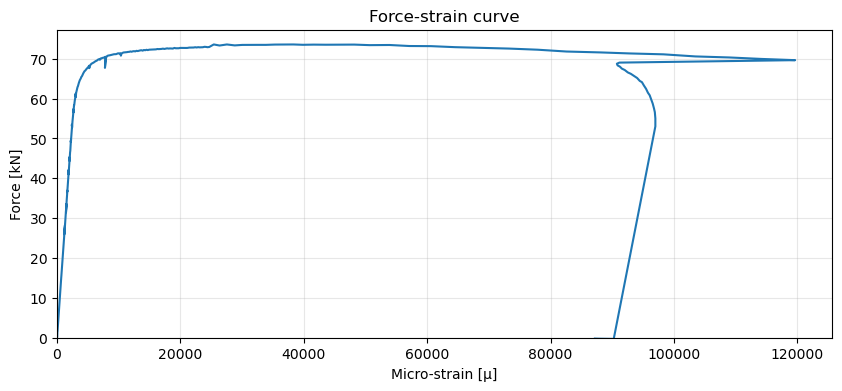

In [25]:
y = df['force']
x = df['strain']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, y)
ax.set_title('Force-strain curve') 
ax.set_ylabel('Force [kN]') 
ax.set_xlabel('Micro-strain [μ]')
ax.set_xlim([0, None])
ax.set_ylim([0, None])
ax.grid(True, alpha=0.3)
plt.show()

## Explore data

In [26]:
df.head(150)

,displacement,force,strain
0,0.000,0.000,0.000
1,0.000,0.000,0.000
2,0.000,0.000,0.000
3,0.000,0.000,0.000
4,0.000,0.000,0.000
...,...,...,...
145,2.217,40.630,1845.594
146,2.217,41.095,1866.385
147,2.234,41.496,1890.528
148,2.300,42.037,1821.451


In [27]:
df.tail()

,displacement,force,strain
403,12.163,-0.233,87332.689
404,12.229,-0.216,87290.022
405,12.229,-0.215,87257.593
406,12.246,-0.218,87236.164
407,12.229,-0.220,87193.210


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  408 non-null    float64
 1   force         408 non-null    float64
 2   strain        408 non-null    float64
dtypes: float64(3)
memory usage: 9.7 KB


In [29]:
df["force"].dtype

dtype('float64')

## Manipulate the data

In [30]:
# Modify column values
df['strain']=df['strain']/1e6
df

,displacement,force,strain
0,0.000,0.000,0.000000
1,0.000,0.000,0.000000
2,0.000,0.000,0.000000
3,0.000,0.000,0.000000
4,0.000,0.000,0.000000
...,...,...,...
403,12.163,-0.233,0.087333
404,12.229,-0.216,0.087290
405,12.229,-0.215,0.087258
406,12.246,-0.218,0.087236


In [31]:
# Create a copy a dataframe
df_copy = df.copy()
df_copy

,displacement,force,strain
0,0.000,0.000,0.000000
1,0.000,0.000,0.000000
2,0.000,0.000,0.000000
3,0.000,0.000,0.000000
4,0.000,0.000,0.000000
...,...,...,...
403,12.163,-0.233,0.087333
404,12.229,-0.216,0.087290
405,12.229,-0.215,0.087258
406,12.246,-0.218,0.087236


In [32]:
# Vectorised calculations
# Insert a column - Direct Assignment
area = 15**2/4 * np.pi ## mm^2
df_copy["stress"] = df_copy['force']/area*1000
df_copy

,displacement,force,strain,stress
0,0.000,0.000,0.000000,0.000000
1,0.000,0.000,0.000000,0.000000
2,0.000,0.000,0.000000,0.000000
3,0.000,0.000,0.000000,0.000000
4,0.000,0.000,0.000000,0.000000
...,...,...,...,...
403,12.163,-0.233,0.087333,-1.318510
404,12.229,-0.216,0.087290,-1.222310
405,12.229,-0.215,0.087258,-1.216651
406,12.246,-0.218,0.087236,-1.233628


In [33]:
# Insert a column - Control of column position
area = 15**2/4 * np.pi
df.insert(2, "stress", df['force']/area*1000)
df

,displacement,force,stress,strain
0,0.000,0.000,0.000000,0.000000
1,0.000,0.000,0.000000,0.000000
2,0.000,0.000,0.000000,0.000000
3,0.000,0.000,0.000000,0.000000
4,0.000,0.000,0.000000,0.000000
...,...,...,...,...
403,12.163,-0.233,-1.318510,0.087333
404,12.229,-0.216,-1.222310,0.087290
405,12.229,-0.215,-1.216651,0.087258
406,12.246,-0.218,-1.233628,0.087236


In [34]:
# Remove column
df_copy = df_copy.drop('force', axis=1)
df_copy

,displacement,strain,stress
0,0.000,0.000000,0.000000
1,0.000,0.000000,0.000000
2,0.000,0.000000,0.000000
3,0.000,0.000000,0.000000
4,0.000,0.000000,0.000000
...,...,...,...
403,12.163,0.087333,-1.318510
404,12.229,0.087290,-1.222310
405,12.229,0.087258,-1.216651
406,12.246,0.087236,-1.233628


In [35]:
# Remove row
df_copy = df_copy.drop(407, axis=0)
df_copy

,displacement,strain,stress
0,0.000,0.000000,0.000000
1,0.000,0.000000,0.000000
2,0.000,0.000000,0.000000
3,0.000,0.000000,0.000000
4,0.000,0.000000,0.000000
...,...,...,...
402,12.080,0.087381,-1.352463
403,12.163,0.087333,-1.318510
404,12.229,0.087290,-1.222310
405,12.229,0.087258,-1.216651


In [36]:
# Insert row
# Create a DataFrame for the new row
new_row_df = pd.DataFrame([{"displacement": 13, "strain": 0.09, "stress": --1.3}])

# Index position
insert_pos = 404

# Split DataFrame above and below
df_top = df_copy.iloc[:insert_pos]
df_bottom = df_copy.iloc[insert_pos:]

# Concatenate data
df_copy2 = pd.concat([df_top, new_row_df, df_bottom], ignore_index=True)

df_copy2.tail()

,displacement,strain,stress
403,12.163,0.087333,-1.318510
404,13.000,0.090000,1.300000
405,12.229,0.087290,-1.222310
406,12.229,0.087258,-1.216651
407,12.246,0.087236,-1.233628


In [37]:
# Rename column
df.rename(columns={'force': 'load'})

,displacement,load,stress,strain
0,0.000,0.000,0.000000,0.000000
1,0.000,0.000,0.000000,0.000000
2,0.000,0.000,0.000000,0.000000
3,0.000,0.000,0.000000,0.000000
4,0.000,0.000,0.000000,0.000000
...,...,...,...,...
403,12.163,-0.233,-1.318510,0.087333
404,12.229,-0.216,-1.222310,0.087290
405,12.229,-0.215,-1.216651,0.087258
406,12.246,-0.218,-1.233628,0.087236


In [38]:
df

,displacement,force,stress,strain
0,0.000,0.000,0.000000,0.000000
1,0.000,0.000,0.000000,0.000000
2,0.000,0.000,0.000000,0.000000
3,0.000,0.000,0.000000,0.000000
4,0.000,0.000,0.000000,0.000000
...,...,...,...,...
403,12.163,-0.233,-1.318510,0.087333
404,12.229,-0.216,-1.222310,0.087290
405,12.229,-0.215,-1.216651,0.087258
406,12.246,-0.218,-1.233628,0.087236


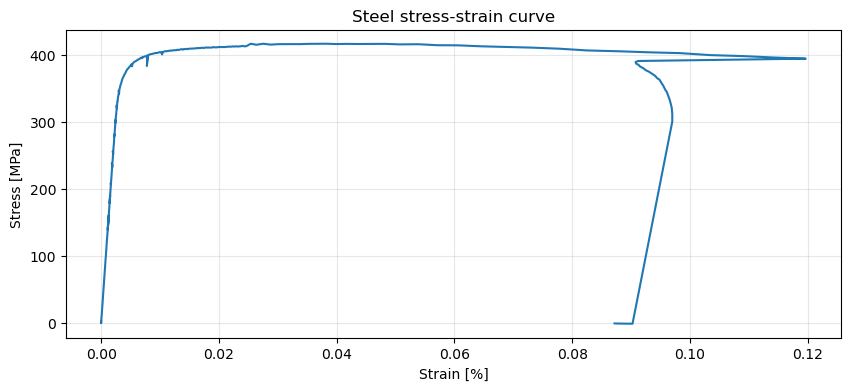

In [39]:
y = df['stress']
x = df['strain']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, y)
ax.set_title('Steel stress-strain curve') 
ax.set_ylabel('Stress [MPa]') 
ax.set_xlabel('Strain [%]')
# ax.set_xlim([0, None])
# ax.set_ylim([0, None])
ax.grid(True, alpha=0.3)
plt.show()

## Filtering data

In [40]:
df[df["stress"] > 300]

,displacement,force,stress,strain
174,2.829,53.155,300.795769,0.002440
175,2.829,53.450,302.465127,0.002389
177,2.896,53.813,304.519287,0.002481
178,2.896,54.299,307.269485,0.002505
179,2.896,54.698,309.527363,0.002537
...,...,...,...,...
380,10.210,58.782,332.638075,0.096561
381,10.326,57.531,325.558863,0.096775
382,10.359,56.611,320.352728,0.096909
383,10.492,55.030,311.406098,0.096995


In [41]:
df.loc[df["stress"] > 300, 'stress']

174    300.795769
175    302.465127
177    304.519287
178    307.269485
179    309.527363
          ...    
380    332.638075
381    325.558863
382    320.352728
383    311.406098
384    300.099731
Name: stress, Length: 210, dtype: float64

In [42]:
# df.at[df["stress"] > 300, 'stress']

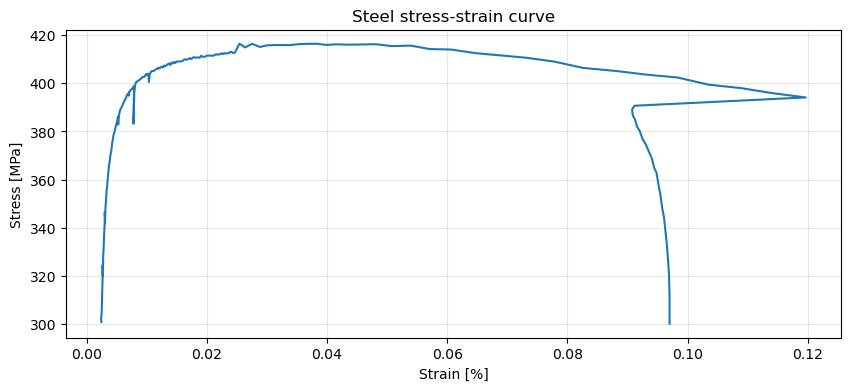

In [43]:
y = df.loc[df["stress"] > 300, 'stress']
x = df.loc[df["stress"] > 300, 'strain']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, y)
ax.set_title('Steel stress-strain curve') 
ax.set_ylabel('Stress [MPa]') 
ax.set_xlabel('Strain [%]')
# ax.set_xlim([0, None])
# ax.set_ylim([0, None])
ax.grid(True, alpha=0.3)
plt.show()

In [44]:
# Get closest value

target = 0.01

# Absolute difference for all the values
diff = (df["strain"] - target).abs()

# Minimum difference
min_diff = diff.min()

# Mask of vals equal to minimum difference
closest_values = df[diff == min_diff]

closest_values

,displacement,force,stress,strain
263,4.7,71.32,403.588641,0.010078


In [45]:
diff

0      0.010000
1      0.010000
2      0.010000
3      0.010000
4      0.010000
         ...   
403    0.077333
404    0.077290
405    0.077258
406    0.077236
407    0.077193
Name: strain, Length: 408, dtype: float64

In [46]:
diff.min()

7.766799999999949e-05

## Group results

In [47]:
df.agg(["sum", "min"])

,displacement,force,stress,strain
sum,1604.366,17918.586,101398.454582,7.742320
min,-0.017,-0.301,-1.703312,-0.000001


In [48]:
df = pd.DataFrame({'Material': ["Steel", "Concrete","Steel", "Concrete"], 'E': [205E9,30E9,195E9,35E9], 'f_y': [355,35,340,40]})
df

,Material,E,f_y
0,Steel,2.050000e+11,355
1,Concrete,3.000000e+10,35
2,Steel,1.950000e+11,340
3,Concrete,3.500000e+10,40


In [49]:
df.groupby("Material").mean()

,E,f_y
Material,,
Concrete,3.250000e+10,37.5
Steel,2.000000e+11,347.5


## Merge data

#### `pd.concat`

In [50]:
df1 = pd.DataFrame({'Material': ["Steel"], 'E': [205E9], 'f_y': [355]})
df2 = pd.DataFrame({'Material': ["Concrete"], 'E': [30E9], 'f_y': [35]})
df1

,Material,E,f_y
0,Steel,2.050000e+11,355


In [51]:
# Concatenate vertically
concatenated = pd.concat([df1, df2], axis=0, ignore_index=True)
concatenated


,Material,E,f_y
0,Steel,2.050000e+11,355
1,Concrete,3.000000e+10,35


In [52]:
# Merge along the columns
df1 = pd.DataFrame({'Material': ["Steel", "Concrete"], 'E': [205E9,30E9]})
df2 = pd.DataFrame({'Material': ["Steel", "Concrete"], 'f_y': [355,35]})
df1

,Material,E
0,Steel,2.050000e+11
1,Concrete,3.000000e+10


In [53]:
# Concatenate horizontally
concatenated = pd.concat([df1, df2], axis=1)
concatenated

,Material,E,Material,f_y
0,Steel,2.050000e+11,Steel,355
1,Concrete,3.000000e+10,Concrete,35


#### `pd.merge`

In [54]:
elements = pd.DataFrame({
    "ElementID": [101, 102, 103, 104],
    "Section": ["B1", "B2", "B1", "B2"]
})
elements

,ElementID,Section
0,101,B1
1,102,B2
2,103,B1
3,104,B2


In [55]:
stresses = pd.DataFrame({
    "ElementID": [101, 102, 104],
    "F_Ed": [150, 250, 220],
})
stresses

,ElementID,F_Ed
0,101,150
1,102,250
2,104,220


In [56]:
sections = pd.DataFrame({
    "Section": ["B1", "B2"],
    "F_Rd": [180, 240]
})
sections

,Section,F_Rd
0,B1,180
1,B2,240


In [57]:
merged1 = pd.merge(elements, stresses, on="ElementID", how="left")
merged1

,ElementID,Section,F_Ed
0,101,B1,150.0
1,102,B2,250.0
2,103,B1,NaN
3,104,B2,220.0


In [58]:
merged2 = pd.merge(merged1, sections, on="Section", how="left")
merged2

,ElementID,Section,F_Ed,F_Rd
0,101,B1,150.0,180
1,102,B2,250.0,240
2,103,B1,NaN,180
3,104,B2,220.0,240


In [59]:
# Show only rows where F_Ed > F_Rd
merged2[merged2["F_Rd"] < merged2["F_Ed"]]

,ElementID,Section,F_Ed,F_Rd
1,102,B2,250.0,240
